In [2]:
from pymongo import MongoClient
import matplotlib.pyplot as plt

In [4]:
import pandas as pd

titanic = pd.read_csv('C:\\Users\\piotr\\Downloads\\titanic\\train.csv')
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [4]:
client = MongoClient("mongodb://localhost:27017/")
db = client["titanic_db"]
collection = db["passengers"]

In [8]:
data_dict = titanic.to_dict("records")
collection.insert_many(data_dict)

InsertManyResult([ObjectId('683d623de3eb47ab00cdbfeb'), ObjectId('683d623de3eb47ab00cdbfec'), ObjectId('683d623de3eb47ab00cdbfed'), ObjectId('683d623de3eb47ab00cdbfee'), ObjectId('683d623de3eb47ab00cdbfef'), ObjectId('683d623de3eb47ab00cdbff0'), ObjectId('683d623de3eb47ab00cdbff1'), ObjectId('683d623de3eb47ab00cdbff2'), ObjectId('683d623de3eb47ab00cdbff3'), ObjectId('683d623de3eb47ab00cdbff4'), ObjectId('683d623de3eb47ab00cdbff5'), ObjectId('683d623de3eb47ab00cdbff6'), ObjectId('683d623de3eb47ab00cdbff7'), ObjectId('683d623de3eb47ab00cdbff8'), ObjectId('683d623de3eb47ab00cdbff9'), ObjectId('683d623de3eb47ab00cdbffa'), ObjectId('683d623de3eb47ab00cdbffb'), ObjectId('683d623de3eb47ab00cdbffc'), ObjectId('683d623de3eb47ab00cdbffd'), ObjectId('683d623de3eb47ab00cdbffe'), ObjectId('683d623de3eb47ab00cdbfff'), ObjectId('683d623de3eb47ab00cdc000'), ObjectId('683d623de3eb47ab00cdc001'), ObjectId('683d623de3eb47ab00cdc002'), ObjectId('683d623de3eb47ab00cdc003'), ObjectId('683d623de3eb47ab00cdc0

In [9]:
nowy_pasazer = {
    "PassengerId": 999,
    "Survived": 0,
    "Pclass": 3,
    "Name": "Nowak, Mr. Jan",
    "Sex": "male",
    "Age": 30,
    "SibSp": 0,
    "Parch": 0,
    "Ticket": "A/5 21171",
    "Fare": 7.25,
    "Cabin": "",
    "Embarked": "S"
}
collection.insert_one(nowy_pasazer)


InsertOneResult(ObjectId('683d6300e3eb47ab00cdc366'), acknowledged=True)

In [11]:
kobiety = list(collection.find({"Sex": "female"}))
df_kobiety = pd.DataFrame(kobiety)
print(df_kobiety.head())

                        _id  PassengerId  Survived  Pclass  \
0  683d623de3eb47ab00cdbfec            2         1       1   
1  683d623de3eb47ab00cdbfed            3         1       3   
2  683d623de3eb47ab00cdbfee            4         1       1   
3  683d623de3eb47ab00cdbff3            9         1       3   
4  683d623de3eb47ab00cdbff4           10         1       2   

                                                Name     Sex   Age  SibSp  \
0  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
1                             Heikkinen, Miss. Laina  female  26.0      0   
2       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
3  Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)  female  27.0      0   
4                Nasser, Mrs. Nicholas (Adele Achem)  female  14.0      1   

   Parch            Ticket     Fare Cabin Embarked  
0      0          PC 17599  71.2833   C85        C  
1      0  STON/O2. 3101282   7.9250   NaN        S  
2    

In [12]:
collection.update_one(
    {"Name": "Nowak, Mr. Jan"},
    {"$set": {"Age": 31}}
)
zaktualizowany = collection.find_one({"Name": "Nowak, Mr. Jan"})
print(zaktualizowany)


{'_id': ObjectId('683d6300e3eb47ab00cdc366'), 'PassengerId': 999, 'Survived': 0, 'Pclass': 3, 'Name': 'Nowak, Mr. Jan', 'Sex': 'male', 'Age': 31, 'SibSp': 0, 'Parch': 0, 'Ticket': 'A/5 21171', 'Fare': 7.25, 'Cabin': '', 'Embarked': 'S'}


In [13]:
collection.delete_one({"Name": "Nowak, Mr. Jan"})
usuniety = collection.find_one({"Name": "Nowak, Mr. Jan"})
print(usuniety)

None


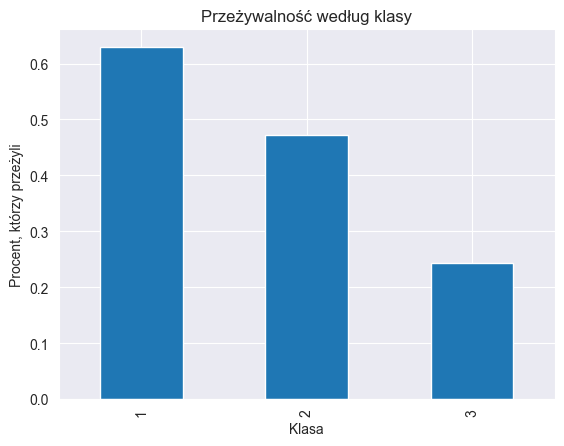

In [17]:
wszyscy = list(collection.find())
df_wszyscy = pd.DataFrame(wszyscy)

przezywalnosc_klasa = df_wszyscy.groupby('Pclass')['Survived'].mean()
przezywalnosc_klasa.plot(kind='bar')
plt.title("Przeżywalność według klasy")
plt.xlabel("Klasa")
plt.ylabel("Procent, którzy przeżyli")
plt.show()


In [17]:
import pandas as pd
from pymongo import MongoClient
import datetime

df = pd.read_csv("C:\\Users\\piotr\\Downloads\\tmdb_5000_movies.csv") 
client = MongoClient("mongodb://localhost:27017/")
db = client["imdb_database"]
collection = db["movies"]

df['rok'] = pd.to_datetime(df["release_date"]).dt.year
print(df['rok'].head())

data = df.to_dict(orient="records")

collection.delete_many({})
collection.insert_many(data)

print("Dane zostały załadowane do MongoDB.")


0    2009.0
1    2007.0
2    2015.0
3    2012.0
4    2012.0
Name: rok, dtype: float64
Dane zostały załadowane do MongoDB.


In [20]:
pipeline = [
    {"$group": {"_id": "$rok", "max_rating": {"$max": "$popularity"}}},
    {"$sort": {"_id": 1}}
]

results = collection.aggregate(pipeline)

result_list = list(results)
for result in result_list:
    print(result)

{'_id': nan, 'max_rating': 0.0}
{'_id': 1916.0, 'max_rating': 3.232447}
{'_id': 1925.0, 'max_rating': 0.785744}
{'_id': 1927.0, 'max_rating': 32.351527}
{'_id': 1929.0, 'max_rating': 1.824184}
{'_id': 1930.0, 'max_rating': 8.484123}
{'_id': 1932.0, 'max_rating': 1.199451}
{'_id': 1933.0, 'max_rating': 1.933366}
{'_id': 1934.0, 'max_rating': 11.871424}
{'_id': 1935.0, 'max_rating': 3.898498}
{'_id': 1936.0, 'max_rating': 28.27648}
{'_id': 1937.0, 'max_rating': 80.171283}
{'_id': 1938.0, 'max_rating': 3.426314}
{'_id': 1939.0, 'max_rating': 67.417542}
{'_id': 1940.0, 'max_rating': 46.007991}
{'_id': 1941.0, 'max_rating': 7.70019}
{'_id': 1942.0, 'max_rating': 47.651878}
{'_id': 1944.0, 'max_rating': 0.628051}
{'_id': 1945.0, 'max_rating': 11.145915}
{'_id': 1946.0, 'max_rating': 42.868495}
{'_id': 1947.0, 'max_rating': 8.055084}
{'_id': 1948.0, 'max_rating': 5.344815}
{'_id': 1949.0, 'max_rating': 8.535178}
{'_id': 1950.0, 'max_rating': 1.726175}
{'_id': 1951.0, 'max_rating': 14.884756}


In [21]:
# Załaduj wyniki z MongoDB do Pandas DataFrame
df_results = pd.DataFrame(result_list)

# Wyświetl przetworzone dane
print(df_results)


       _id  max_rating
0      NaN    0.000000
1   1916.0    3.232447
2   1925.0    0.785744
3   1927.0   32.351527
4   1929.0    1.824184
..     ...         ...
86  2013.0  165.125366
87  2014.0  724.247784
88  2015.0  875.581305
89  2016.0  514.569956
90  2017.0    0.710870

[91 rows x 2 columns]


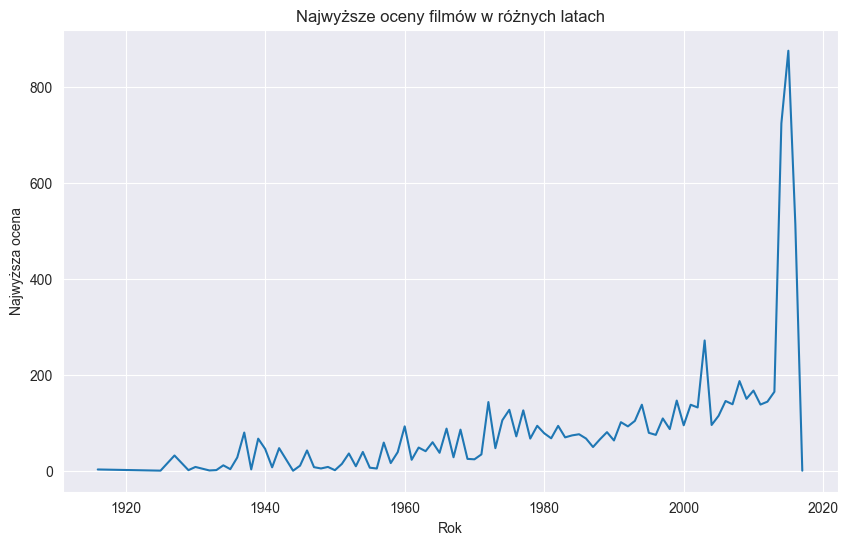

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Wykres zależności między rokiem a najwyższą oceną
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_results, x='_id', y='max_rating')

plt.title('Najwyższe oceny filmów w różnych latach')
plt.xlabel('Rok')
plt.ylabel('Najwyższa ocena')
plt.show()

### 4 zad

In [10]:
import requests

TOKEN = 'GKYjCfTPwYaJMOkkyvnoATwEkvuDjkoC'
url = 'https://www.ncdc.noaa.gov/cdo-web/api/v2/stations'
headers = {'token': TOKEN}
params = {
    'locationid': 'FIPS:PL',
    'limit': 100  # liczba zwracanych stacji, np. 10 pierwszych
}

response = requests.get(url, headers=headers, params=params)
if response.status_code == 200:
    stations = response.json()['results']
    for s in stations:
        print(f"{s['id']}: {s['name']}")
else:
    print('Błąd:', response.status_code, response.text)

GHCND:PL000012120: LEBA, PL
GHCND:PL000012385: SIEDLCE, PL
GHCND:PLM00012160: ELBLAG MILEJEWO, PL
GHCND:PLM00012205: SZCZECIN, PL
GHCND:PLM00012295: BIALYSTOK, PL
GHCND:PLM00012330: LAWICA, PL
GHCND:PLM00012375: OKECIE, PL
GHCND:PLM00012424: STRACHOWICE, PL
GHCND:PLM00012497: WLODAWA, PL
GHCND:PLM00012566: BALICE, PL


In [11]:
TOKEN = 'GKYjCfTPwYaJMOkkyvnoATwEkvuDjkoC'
url = 'https://www.ncdc.noaa.gov/cdo-web/api/v2/data'
headers = {'token': TOKEN}
params = {
    'datasetid': 'GHCND',
    'stationid': 'GHCND:PLM00012375',
    'startdate': '2015-01-01',
    'enddate': '2015-12-31',
    'datatypeid': ['TAVG', 'TMAX', 'TMIN'],
    'limit': 1000
}

response = requests.get(url, headers=headers, params=params)
if response.status_code == 200:
    data = response.json()
    print(len(data.get('results', [])), "rekordów")
    print(data.get('results', []))
else:
    print('Błąd:', response.status_code, response.text)

627 rekordów
[{'date': '2015-01-01T00:00:00', 'datatype': 'TAVG', 'station': 'GHCND:PLM00012375', 'attributes': 'H,,S,', 'value': 16}, {'date': '2015-01-01T00:00:00', 'datatype': 'TMIN', 'station': 'GHCND:PLM00012375', 'attributes': ',,S,', 'value': -12}, {'date': '2015-01-02T00:00:00', 'datatype': 'TAVG', 'station': 'GHCND:PLM00012375', 'attributes': 'H,,S,', 'value': 40}, {'date': '2015-01-02T00:00:00', 'datatype': 'TMIN', 'station': 'GHCND:PLM00012375', 'attributes': ',,S,', 'value': 10}, {'date': '2015-01-03T00:00:00', 'datatype': 'TAVG', 'station': 'GHCND:PLM00012375', 'attributes': 'H,,S,', 'value': 31}, {'date': '2015-01-03T00:00:00', 'datatype': 'TMAX', 'station': 'GHCND:PLM00012375', 'attributes': ',,S,', 'value': 56}, {'date': '2015-01-04T00:00:00', 'datatype': 'TAVG', 'station': 'GHCND:PLM00012375', 'attributes': 'H,,S,', 'value': 21}, {'date': '2015-01-04T00:00:00', 'datatype': 'TMAX', 'station': 'GHCND:PLM00012375', 'attributes': ',,S,', 'value': 36}, {'date': '2015-01-04T

In [12]:
import requests

TOKEN = "GKYjCfTPwYaJMOkkyvnoATwEkvuDjkoC"
url = 'https://www.ncdc.noaa.gov/cdo-web/api/v2/data'
headers = {'token': TOKEN}
params_2025 = {
    'datasetid': 'GHCND',
    'stationid': 'GHCND:PLM00012375',
    'startdate': '2024-01-01',
    'enddate': '2024-12-31',
    'datatypeid': ['TAVG', 'TMAX', 'TMIN'],
    'limit': 1000
}

response_2025 = requests.get(url, headers=headers, params=params_2025)
if response_2025.status_code == 200:
    data_2025 = response_2025.json()
    print(len(data_2025.get('results', [])), "rekordów (2025)")
    print(data_2025.get('results', []))
else:
    print('Błąd:', response_2025.status_code, response_2025.text)

785 rekordów (2025)
[{'date': '2024-01-01T00:00:00', 'datatype': 'TAVG', 'station': 'GHCND:PLM00012375', 'attributes': 'H,,S,', 'value': 28}, {'date': '2024-01-02T00:00:00', 'datatype': 'TAVG', 'station': 'GHCND:PLM00012375', 'attributes': 'H,,S,', 'value': 44}, {'date': '2024-01-03T00:00:00', 'datatype': 'TAVG', 'station': 'GHCND:PLM00012375', 'attributes': 'H,,S,', 'value': 56}, {'date': '2024-01-04T00:00:00', 'datatype': 'TAVG', 'station': 'GHCND:PLM00012375', 'attributes': 'H,,S,', 'value': 59}, {'date': '2024-01-04T00:00:00', 'datatype': 'TMAX', 'station': 'GHCND:PLM00012375', 'attributes': ',,S,', 'value': 81}, {'date': '2024-01-05T00:00:00', 'datatype': 'TAVG', 'station': 'GHCND:PLM00012375', 'attributes': 'H,,S,', 'value': -18}, {'date': '2024-01-05T00:00:00', 'datatype': 'TMAX', 'station': 'GHCND:PLM00012375', 'attributes': ',,S,', 'value': 46}, {'date': '2024-01-06T00:00:00', 'datatype': 'TAVG', 'station': 'GHCND:PLM00012375', 'attributes': 'H,,S,', 'value': -24}, {'date': '2

Empty DataFrame
Columns: []
Index: []


In [13]:
client = MongoClient("mongodb://localhost:27017/")
mydb = client["mydatatabase"]
mycol = mydb['weather']
# Zapisz dane z 2015 
if 'results' in data and data['results']:
    mycol.insert_many(data['results'])
    print(f"Wstawiono {len(data['results'])} rekordów z 2015 roku")
else:
    print("Brak danych z 2015 do zapisania.")

# Zapisz dane z 2024
if 'results' in data_2025 and data_2025['results']:
    mycol.insert_many(data_2025['results'])
    print(f"Wstawiono {len(data_2025['results'])} rekordów z 2024 roku")
else:
    print("Brak danych z 2024 do zapisania.")

Wstawiono 627 rekordów z 2015 roku
Wstawiono 785 rekordów z 2024 roku


In [14]:
import pandas as pd
data = list(mycol.find({
    "datatype": "TAVG",
    "$or": [
        {"date": {"$regex": "^2015"}},
        {"date": {"$regex": "^2024"}}
    ]
}))

df = pd.DataFrame(data)
print(df.head())

                        _id                 date datatype            station  \
0  684c589240aff39c70f40be7  2024-01-01T00:00:00     TAVG  GHCND:PLM00012375   
1  684c589240aff39c70f40be8  2024-01-02T00:00:00     TAVG  GHCND:PLM00012375   
2  684c589240aff39c70f40be9  2024-01-03T00:00:00     TAVG  GHCND:PLM00012375   
3  684c589240aff39c70f40bea  2024-01-04T00:00:00     TAVG  GHCND:PLM00012375   
4  684c589240aff39c70f40bec  2024-01-05T00:00:00     TAVG  GHCND:PLM00012375   

  attributes  value  
0      H,,S,     28  
1      H,,S,     44  
2      H,,S,     56  
3      H,,S,     59  
4      H,,S,    -18  


In [15]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['temp'] = df['value'] /10
monthly_avg = df.groupby(['year', 'month'])['temp'].mean().reset_index()
print(monthly_avg)

    year  month       temp
0   2015      1   1.416129
1   2015      2   1.171429
2   2015      3   5.641935
3   2015      4   8.663333
4   2015      5  13.458065
5   2015      6  17.876667
6   2015      7  20.280645
7   2015      8  23.396774
8   2015      9  15.530000
9   2015     10   7.761290
10  2015     11   5.330000
11  2015     12   4.800000
12  2024      1  -0.222581
13  2024      2   6.113793
14  2024      3   5.740741
15  2024      4  11.113333
16  2024      5  17.726667
17  2024      6  19.716667
18  2024      7  21.977419
19  2024      8  21.456667
20  2024      9  18.656667
21  2024     10  10.000000
22  2024     11   3.930769
23  2024     12   2.843333


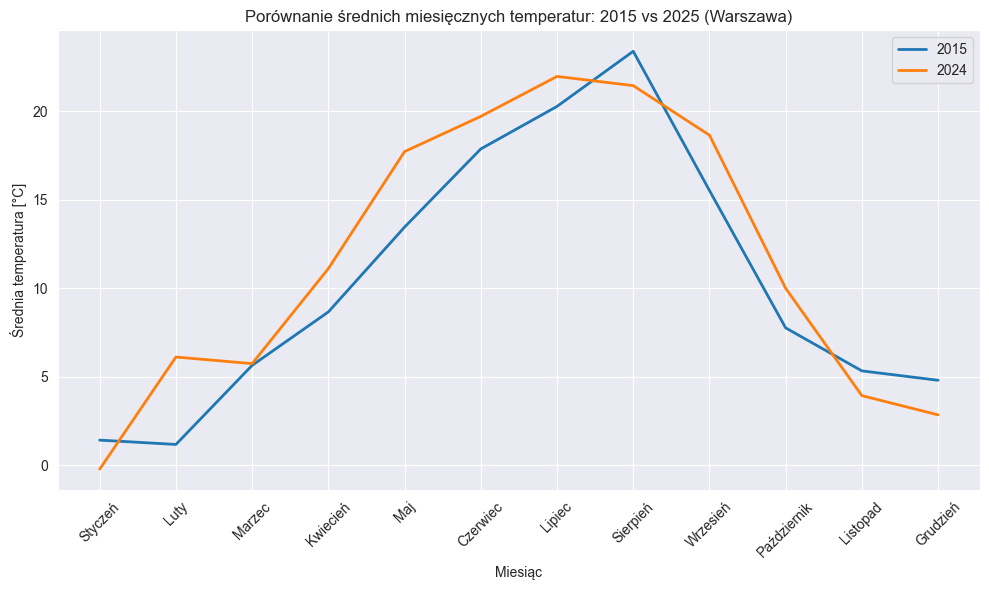

In [16]:
import matplotlib.pyplot as plt

avg_2015 = monthly_avg[monthly_avg['year'] == 2015]
avg_2025 = monthly_avg[monthly_avg['year'] == 2024]

plt.figure(figsize=(10,6))
plt.plot(avg_2015['month'], avg_2015['temp'], label='2015', linewidth=2)
plt.plot(avg_2025['month'], avg_2025['temp'], label='2024', linewidth=2)

plt.xticks(range(1,13), [
    'Styczeń', 'Luty', 'Marzec', 'Kwiecień', 'Maj', 'Czerwiec',
    'Lipiec', 'Sierpień', 'Wrzesień', 'Październik', 'Listopad', 'Grudzień'
], rotation=45)
plt.ylabel('Średnia temperatura [°C]')
plt.xlabel('Miesiąc')
plt.title('Porównanie średnich miesięcznych temperatur: 2015 vs 2025 (Warszawa)')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

In [19]:
import json
import requests
import pandas as pd
from bs4 import BeautifulSoup
from pymongo import MongoClient

In [23]:
import requests
from bs4 import BeautifulSoup

# Przykład: strona kraju (np. Togo) na Climate Change Knowledge Portal
url = "https://climateknowledgeportal.worldbank.org/country/togo"
resp = requests.get(url)
resp.raise_for_status()  # Sprawdź, czy pobranie się powiodło

soup = BeautifulSoup(resp.text, "html.parser")

In [24]:
metrics = {}
for block in soup.select("div.climate-metric"):
    title = block.find("h3").get_text(strip=True)
    value = block.find("p").get_text(strip=True)
    metrics[title] = value

print(metrics)
# Wynik może wyglądać jak:
# {'Mean temperature': '26.5 °C (1991–2020)', 'Mean precipitation': '1200 mm (1991–2020)'}


{}


In [25]:
from pymongo import MongoClient
from datetime import datetime

client = MongoClient("mongodb://localhost:27017")
db = client["climate_db"]
col = db["climate_metrics"]

col.insert_one(document)
print("Dane zostały zapisane do MongoDB:", document)

NameError: name 'document' is not defined